In [1]:
import pandas as pd

In [2]:
diabetes = pd.read_csv('diabetes.csv')

In [3]:
diabetes

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0
...,...,...,...,...,...,...,...,...,...,...
14995,1490300,10,65,60,46,177,33.512468,0.148327,41,1
14996,1744410,2,73,66,27,168,30.132636,0.862252,38,1
14997,1742742,0,93,89,43,57,18.690683,0.427049,24,0
14998,1099353,0,132,98,18,161,19.791645,0.302257,23,0


Diabetic jest zmienną objaśnianą y, zaś pozostałe zmiennymi objaśniającymi X (nie bierzemy pod uwagę PatientID, ponieważ jest to indeks pacjenta i nie jest informatywny dla modelu).

In [5]:
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']  # lista kolumn (cech) używanych do analizy i budowy modelu

target = 'Diabetic'  # nazwa kolumny zawierającej zmienną docelową (czy pacjent ma cukrzycę)

X, y = diabetes[features], diabetes[target]  # podział danych na cechy wejściowe (X) oraz zmienną docelową (y)

print('X:')  # wyświetlenie nagłówka dla cech wejściowych

display(X)  # wyświetlenie tabeli zawierającej wybrane cechy wszystkich pacjentów

print('\ny:')  # wyświetlenie nagłówka dla zmiennej docelowej (\n dodaje pustą linię)

display(y)  # wyświetlenie kolumny informującej, czy pacjent choruje na cukrzycę

X:


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
0,0,171,80,34,23,43.509726,1.213191,21
1,8,92,93,47,36,21.240576,0.158365,23
2,7,115,47,52,35,41.511523,0.079019,23
3,9,103,78,25,304,29.582192,1.282870,43
4,1,85,59,27,35,42.604536,0.549542,22
...,...,...,...,...,...,...,...,...
14995,10,65,60,46,177,33.512468,0.148327,41
14996,2,73,66,27,168,30.132636,0.862252,38
14997,0,93,89,43,57,18.690683,0.427049,24
14998,0,132,98,18,161,19.791645,0.302257,23



y:


0        0
1        0
2        0
3        1
4        0
        ..
14995    1
14996    1
14997    0
14998    0
14999    1
Name: Diabetic, Length: 15000, dtype: int64

# TLUMACZENIE CHATA

Co robi ten kod?

Zakładamy, że diabetes jest obiektem DataFrame z biblioteki Pandas zawierającym dane pacjentów.

1. Wybór cech (features)
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure',
            'TricepsThickness','SerumInsulin','BMI',
            'DiabetesPedigree','Age']

Tworzona jest lista kolumn, które będą używane jako dane wejściowe do modelu.

Znaczenie kolumn:

Kolumna	Opis
Pregnancies	liczba ciąż
PlasmaGlucose	poziom glukozy we krwi
DiastolicBloodPressure	ciśnienie rozkurczowe
TricepsThickness	grubość fałdu skórnego na tricepsie
SerumInsulin	poziom insuliny
BMI	wskaźnik masy ciała
DiabetesPedigree	wskaźnik obciążenia genetycznego cukrzycą
Age	wiek pacjenta
2. Wybór zmiennej docelowej
target = 'Diabetic'

Kolumna Diabetic zawiera informację, czy pacjent ma cukrzycę.

Najczęściej:

0 = brak cukrzycy
1 = cukrzyca
3. Podział danych
X, y = diabetes[features], diabetes[target]

Tworzone są dwa zbiory:

X – dane wejściowe (8 kolumn z cechami pacjenta)

Przykład:

Pregnancies	PlasmaGlucose	BMI	Age
2	95	24.5	30
4	140	31.2	45

y – odpowiedź, którą model ma przewidywać

Diabetic
0
1
4. Wyświetlenie danych
display(X)
display(y)

Pokazuje zawartość obu zmiennych.

Opis wyniku

Otrzymałeś:

y:
0        0
1        0
2        0
3        1
4        0
        ..
14995    1
14996    1
14997    0
14998    0
14999    1
Name: Diabetic, Length: 15000, dtype: int64

To jest seria (Series) Pandas zawierająca wartości kolumny Diabetic.

Jak to czytać?
0        0
pierwszy 0 = indeks wiersza
drugi 0 = wartość w kolumnie Diabetic

Czyli:

Pacjent o indeksie 0 nie ma cukrzycy.

3        1

oznacza:

Pacjent o indeksie 3 ma cukrzycę.

Co oznacza ..?
4        0
        ..
14995    1

Pandas nie pokazuje wszystkich 15000 rekordów, tylko początek i koniec zbioru.

Co oznacza:
Name: Diabetic

Nazwa kolumny, z której pochodzą dane.

Co oznacza:
Length: 15000

W zbiorze znajduje się 15000 pacjentów (rekordów).

Co oznacza:
dtype: int64

Typ danych to liczby całkowite 64-bitowe (integer).

Ponieważ kolumna zawiera tylko wartości 0 i 1, jest to typowe kodowanie dla problemu klasyfikacji binarnej:

0 → osoba zdrowa
1 → osoba chora na cukrzycę

Taki zbiór danych jest przygotowany do uczenia modelu klasyfikacyjnego (np. Logistic Regression, Decision Tree, Random Forest), który na podstawie cech z X będzie przewidywał wartość y (czy pacjent ma cukrzycę).

# cd szkolenia nizej

Zrozumienie, czyli abyśmy wiedzieli, jak dane wpływają na zmienną zależną, czy zmienna nie jest na przykład wyciekiem danych. Tutaj się zatrzymajmy na chwilę. Możesz się zastanawiać jaka zmienna może być wyciekiem. Naprawdę jest to proste! Nie możesz stosować cech, które nie są znane przed wykonywaniem prognozy.

Przykład – załóżmy, że klasyfikujesz czy samolot będzie opóźniony. Nie możesz wykorzystać realnej godziny przylotu, ponieważ ta informacji jest znana dopiero po wylądowaniu i model wykorzystujący taką zmienną byłby nieużyteczny. Ponadto wykorzystując dane, które są wyciekiem danych uzyskujemy zbyt optymistyczne wyniki.

Wróćmy do eksploracji danych, jej celem jest również decyzja o przetwarzaniu danych, czyli usunięcie wartości odstających, tworzenie nowych cech w oparciu o już istniejące (Feature engineering) czy usunięcie zmiennych ze sobą skorelowanych (tak jak w regresji zrobiliśmy dla temperatury oraz temperatury odczuwalnej) lub zmiennych, które nie mają wpływ na zmienną objaśnianą. Pamiętaj, to jest pewien przewodnik, jednak nie jest to zawsze działający przepis! Możesz nauczyć się robić przepyszne ciasto u siebie w domu, ale jeśli ciocia poprosi Cię o zrobienie ciasta w jej kuchni, gdzie foremka i piekarnik są inne, to też należy lekko zmienić przepis, aby ponownie ciasto było przepyszne.

Analizę danych dla problemu klasyfikacji najlepiej zacząć od zmiennej objaśnianej ~ y. Jak już wcześniej się dowiedzieliśmy, ważne aby sprawdzić czy klasy są zbalansowane, czyli czy jest ich po równo. Umieśćmy y w Data Series, a następnie zastosujmy metodę value_counts, dzięki której sprawdzimy unikalne klasy i liczbę ich wystąpień. Parametr normalize domyślnie jest ustawiony na False, zmieniając na True zobaczymy procentowy udział klas – szczególnie przy wielu różnych unikalnych wartościach wynik jest bardziej klarowny.

In [6]:
pd.Series(y).value_counts(normalize=True)

Diabetic
0    0.666667
1    0.333333
Name: proportion, dtype: float64

1/3 badanych osób była cukrzykami. Należy mieć tę informację w pamięci, ponieważ tworząc model, który zawsze klasyfikuje osoby jako nie cukrzyków będzie miał dokładność 66.6667%. Oczywiście taki model nie będzie dobrym, ale o tym już nie raz mogliśmy się przekonać.

Sprawdźmy typy danych oraz sprawdźmy czy są wartości brakujące. Wykorzystamy metodę info na całej ramce danych.

In [7]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               15000 non-null  int64  
 1   Pregnancies             15000 non-null  int64  
 2   PlasmaGlucose           15000 non-null  int64  
 3   DiastolicBloodPressure  15000 non-null  int64  
 4   TricepsThickness        15000 non-null  int64  
 5   SerumInsulin            15000 non-null  int64  
 6   BMI                     15000 non-null  float64
 7   DiabetesPedigree        15000 non-null  float64
 8   Age                     15000 non-null  int64  
 9   Diabetic                15000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.1 MB


# wazne info o brakach danych

Brak wartości brakujących, a typy danych, które się pojawiły to wartości numeryczne. Jeśli pojawiłyby się braki w danych (często tak się dzieje) to należałoby je uzupełnić. Jednak nie możemy uzupełniać braków na całym zbiorze, ponieważ to ponownie wyciek danych! Braki danych uzupełniamy na podstawie wiedzy ze zbioru treningowego, ponieważ zakładamy, że dane ze zbioru testowego są dla nas nieznane. W związku z tym jeśli mamy braki dla wartości numerycznej, to uzupełnić możemy je średnią bądź medianą ze zbioru treningowego, a braki dla wartości kategorycznej uzupełniamy modą, czyli najczęściej występującą kategorią ze zbioru treningowego.

Sprawdźmy rozkłady, wykorzystując metodę describe. W tym przypadku możemy to wykonać jedynie dla X, ponieważ już wiemy, że y to zmienna objaśniana kategoryczna (znamy też jej rozkład).

In [9]:
X.describe()

,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,3.224533,107.856867,71.220667,28.814000,137.852133,31.509646,0.398968,30.137733
std,3.391020,31.981975,16.758716,14.555716,133.068252,9.759000,0.377944,12.089703
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200512,0.078044,21.000000
25%,0.000000,84.000000,58.000000,15.000000,39.000000,21.259887,0.137743,22.000000
50%,2.000000,104.000000,72.000000,31.000000,83.000000,31.767940,0.200297,24.000000
75%,6.000000,129.000000,85.000000,41.000000,195.000000,39.259692,0.616285,35.000000
max,14.000000,192.000000,117.000000,93.000000,799.000000,56.034628,2.301594,77.000000


# WAZNE 

Teraz będziemy porównywać zmienne numeryczne X do zmiennej kategorycznej y. W tym przypadku dobrym pomysłem jest wykorzystanie wykresów pudełkowych (boxplot) – ważne do zapamiętania dla Ciebie w przyszłych projektach. W innych problemach poza zmiennymi numerycznymi może pojawić się oczywiście zmienna kategoryczna, nie możemy zatem wykorzystać boxplota. Dobrym pomysłem jest wykorzystanie wykresu słupkowego (barplot), zobaczysz wtedy jaki jest rozkład y w zależności od kategorii – również ważne do zapamiętania dla Ciebie w przyszłych projektach. Stwórzmy zatem wykresy pudełkowe dla każdej zmiennej, potrzebny będzie to tego również już dobrze przez nas znany matplotlib.

Unique values: 15


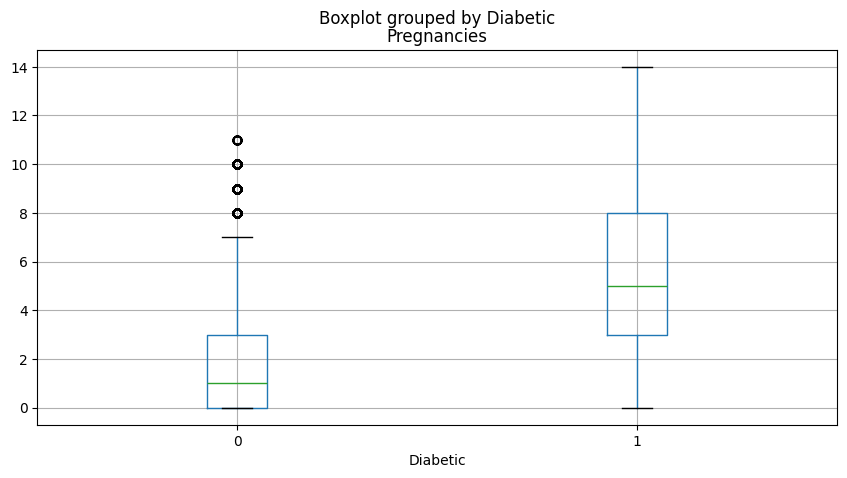

Unique values: 149


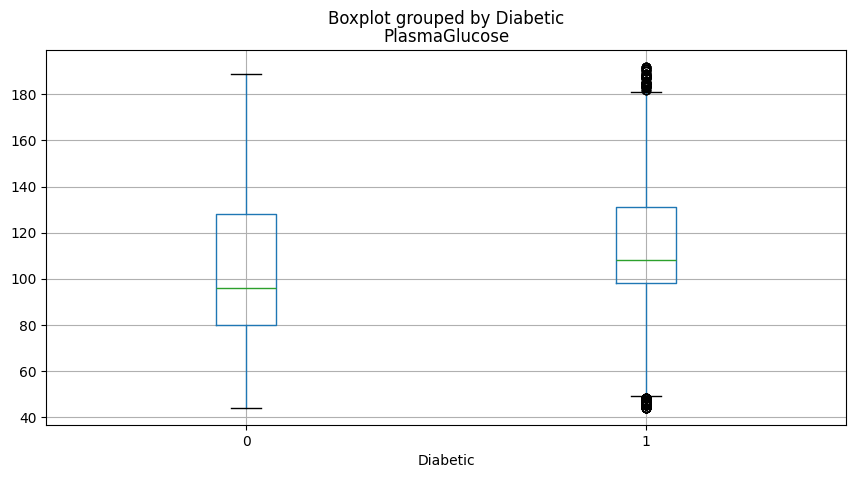

Unique values: 90


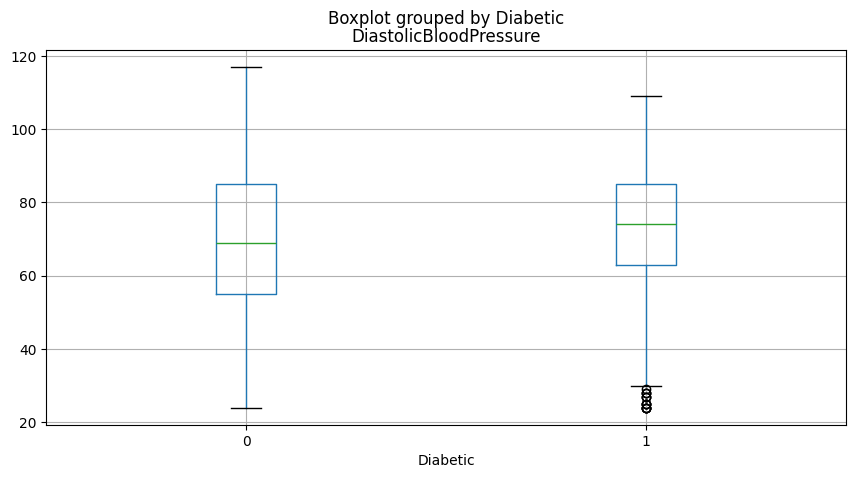

Unique values: 69


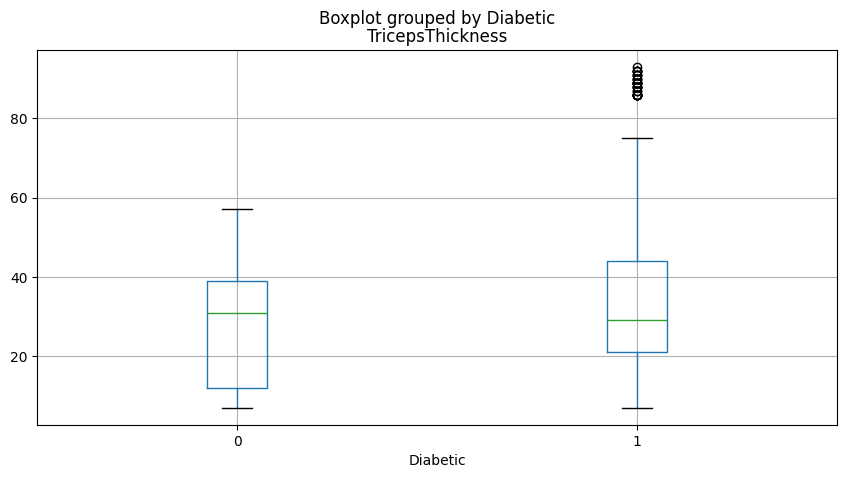

Unique values: 663


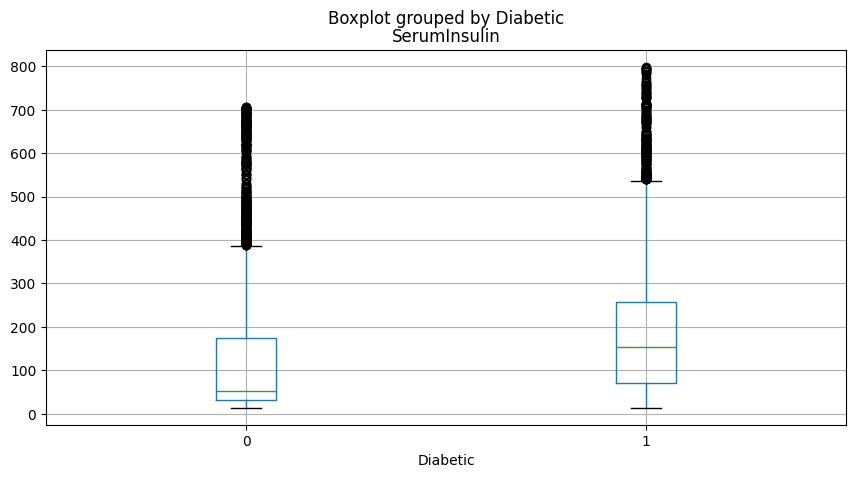

Unique values: 15000


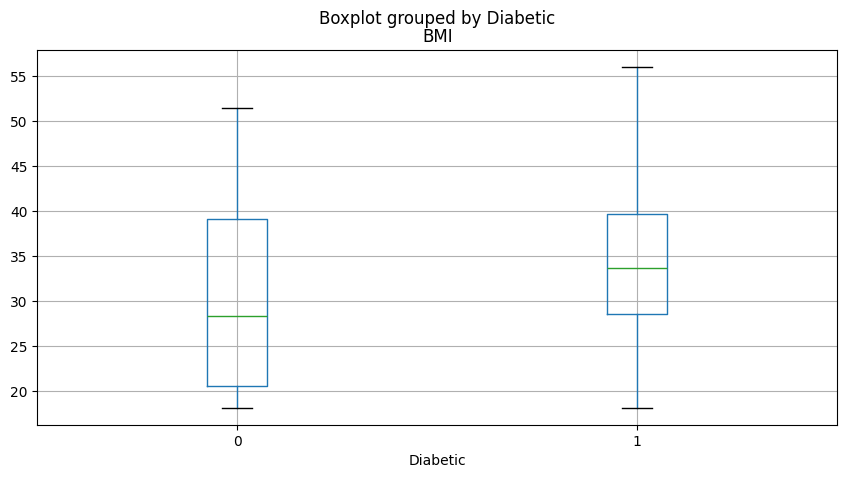

Unique values: 14999


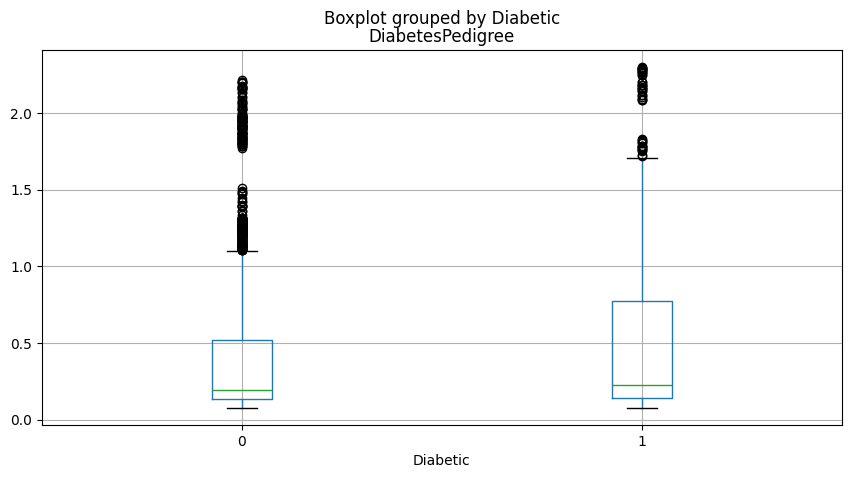

Unique values: 56


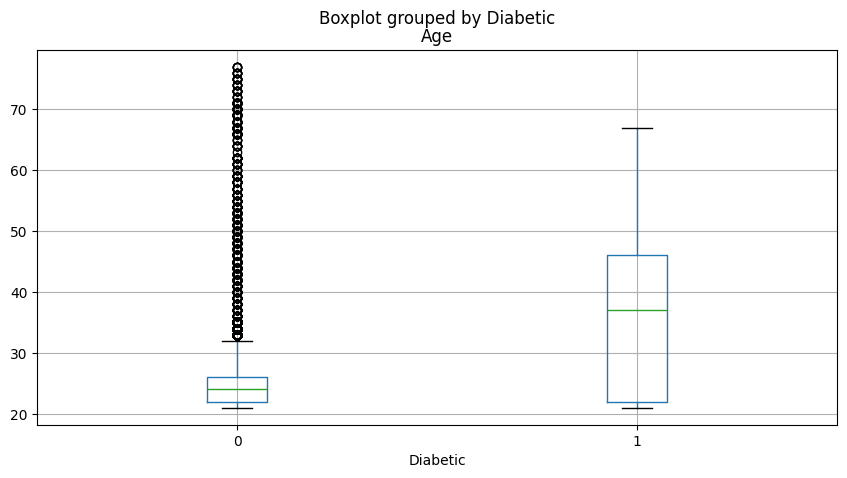

In [17]:
import matplotlib.pyplot as plt  # import biblioteki matplotlib do tworzenia wykresów

for col in features:  # pętla przechodząca przez wszystkie cechy zapisane w liście features

    print(f'Unique values: {len(diabetes[col].unique())}')  # wyświetlenie liczby unikalnych wartości w analizowanej kolumnie

    diabetes.boxplot(column=col, by='Diabetic', figsize=(10,5))  # utworzenie wykresu pudełkowego dla danej cechy z podziałem na osoby chore i zdrowe

    plt.title(col)  # ustawienie nazwy aktualnej kolumny jako tytułu wykresu

    plt.show()  # wyświetlenie wykresu

Jak można zauważyć na podstawie liczby ciąż, BMI czy wieku jesteśmy w stanie oszacować, a idąc dalej – przypisać prawdopodobieństwo bycia cukrzykiem.

Inną wizualizacją, która pozwoli nam ocenić czy dana zmienna wpływa na to, czy ktoś jest cukrzykiem, są histogramy w zależności od naszej zmiennej objaśnianej.

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

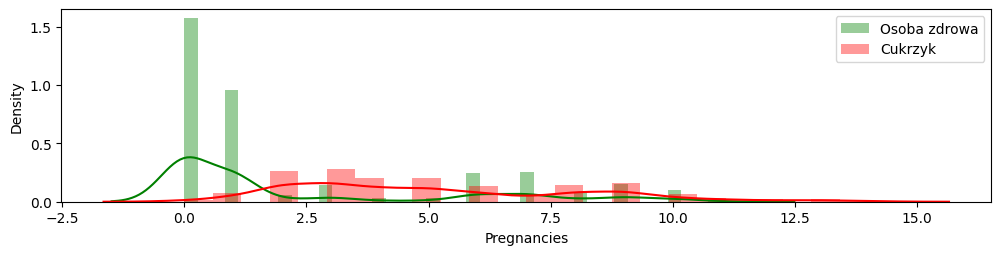

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

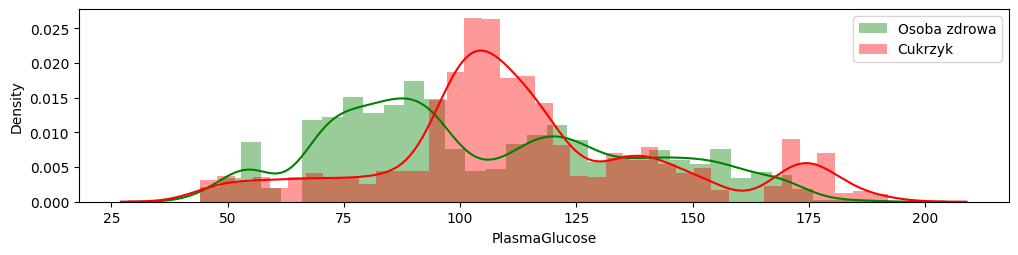

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

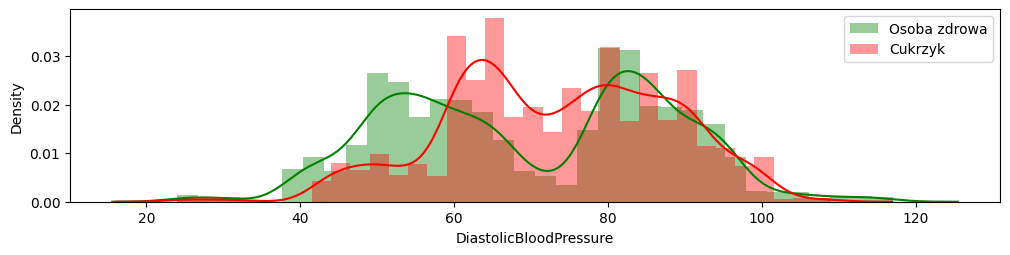

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

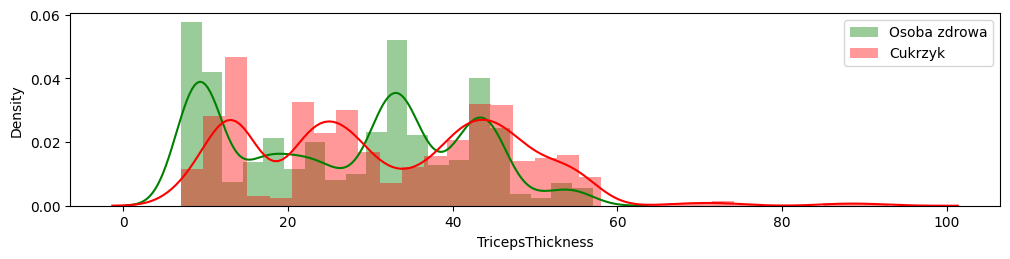

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

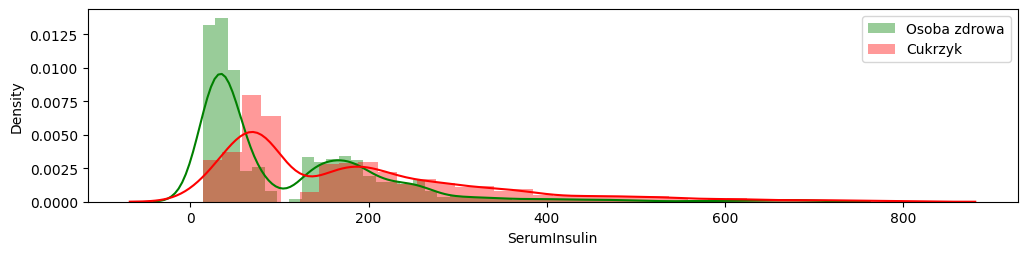

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

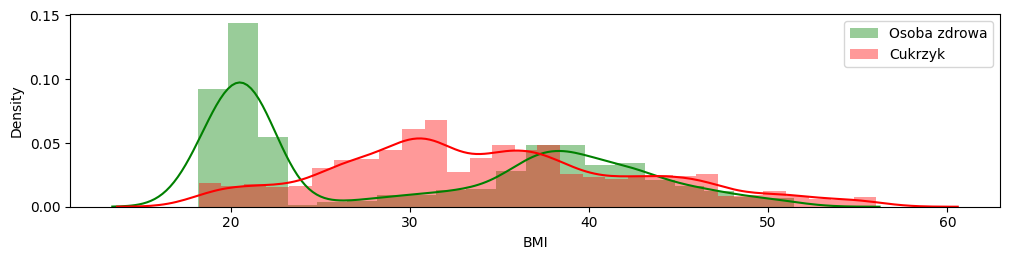

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

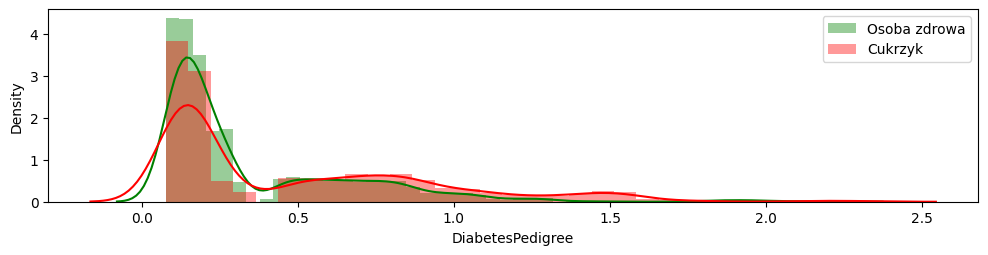

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3377817562.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

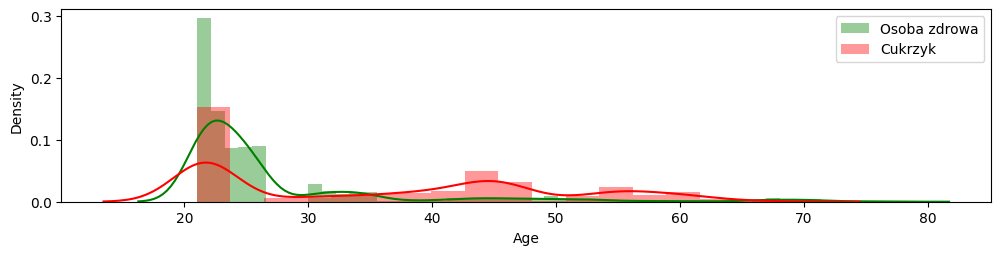

In [15]:
import seaborn as sns
for col in features:
    plt.figure(figsize=(12, 2.5))
    sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
    sns.distplot(diabetes.loc[diabetes['Diabetic']==1, col], kde=True, color='red', label='Cukrzyk')
    plt.legend(loc='upper right')
    plt.show()

W zależności od ‘miejsca’ w rozkładzie dla poszczególnych cech, zmienia się też gęstość klas. Dwa powyższe wykresy dały Ci obraz, jak poszczególne cechy wpływają na to, czy pacjent jest cukrzykiem czy osobą zdrową.

Przypomnij sobie poprzedni moduł o regresji. Zauważyliśmy, że dwie cechy przekazują tę samą informację. Sprawdźmy to również dla tego problemu.

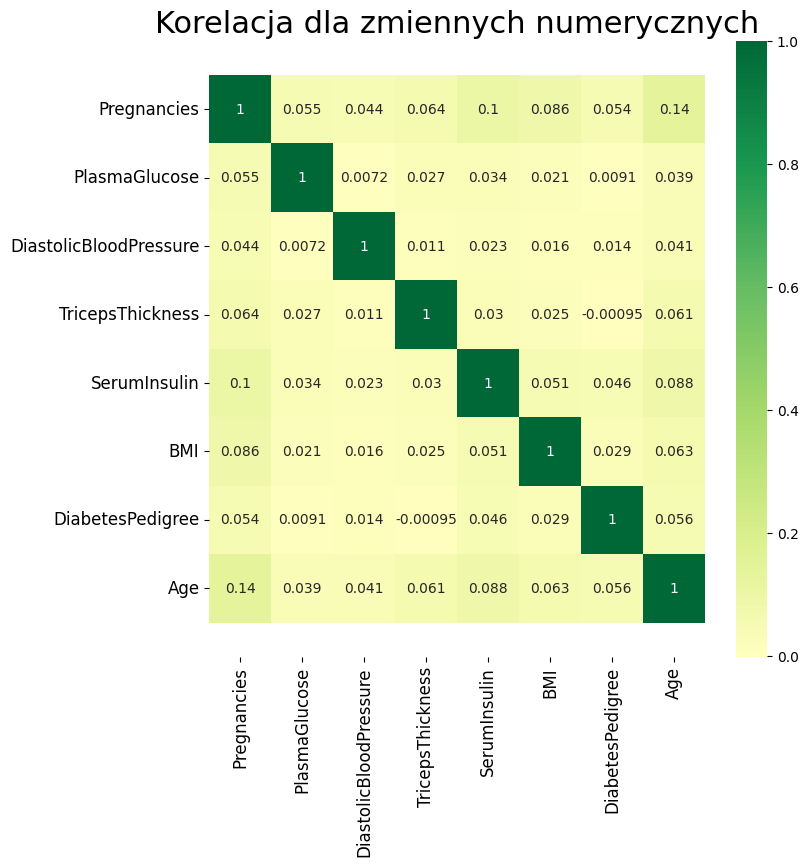

In [16]:
plt.figure(figsize=(8, 8))  # utworzenie nowego okna wykresu o rozmiarze 8x8 cali

ax = sns.heatmap(X.corr(),  # obliczenie macierzy korelacji i utworzenie mapy cieplnej
                 xticklabels=X.corr().columns,  # etykiety osi X - nazwy kolumn
                 yticklabels=X.corr().columns,  # etykiety osi Y - nazwy kolumn
                 cmap='RdYlGn',  # paleta kolorów: czerwony-żółty-zielony
                 center=0,  # wartość 0 będzie środkiem skali kolorów
                 annot=True)  # wyświetlenie wartości współczynników korelacji w komórkach

plt.title('Korelacja dla zmiennych numerycznych', fontsize=22)  # dodanie tytułu wykresu

bottom, top = ax.get_ylim()  # pobranie aktualnych granic osi Y

ax.set_ylim(bottom + 0.5, top - 0.5)  # korekta granic osi Y, aby nie ucinać pierwszego i ostatniego wiersza

plt.xticks(fontsize=12)  # ustawienie rozmiaru czcionki etykiet osi X

plt.yticks(fontsize=12)  # ustawienie rozmiaru czcionki etykiet osi Y

plt.show()  # wyświetlenie gotowego wykresu

Stwierdzić możemy, że zmienne opisują inne wariancje. Hola hola… zapewne pomyślisz teraz, czemu nie liczymy korelacji Pearsona pomiędzy zmiennymi objaśniającymi a zmienną objaśnianą. Nie możemy tego zrobić, ponieważ y to zmienna kategoryczna. Aby policzyć korelację pomiędzy zmienną numeryczną a kategoryczną zastosować możemy współczynnik korelacji punktowo-dwuseryjnej (Point-biserial correlation coefficient). Skorzystajmy z biblioteki scipy.

In [18]:
from scipy import stats  # import modułu stats z biblioteki scipy, który zawiera funkcje statystyczne

corr_dict = {}  # utworzenie pustego słownika do przechowywania korelacji każdej cechy z klasą Diabetic

for col in features:  # przejście przez wszystkie kolumny znajdujące się na liście features

    corr_dict[col] = stats.pointbiserialr(X[col], y)[0]  # obliczenie korelacji punktowo-dwuseryjnej między cechą a zmienną binarną y

pd.Series(corr_dict).sort_values(ascending=False)  # zamiana słownika na serię Pandas i posortowanie wyników malejąco

Pregnancies               0.407315
Age                       0.342605
SerumInsulin              0.247375
BMI                       0.210508
DiabetesPedigree          0.170302
TricepsThickness          0.152505
PlasmaGlucose             0.128004
DiastolicBloodPressure    0.091307
dtype: float64

# TLUMACZENIE CHATA

Dlaczego używamy pointbiserialr?

Funkcja:

stats.pointbiserialr()

liczy korelację punktowo-dwuseryjną.

Jest to specjalny przypadek korelacji Pearsona używany wtedy, gdy:

jedna zmienna jest liczbowa,
druga jest binarna (0/1).

W Twoim przypadku:

PlasmaGlucose -> liczba
Diabetic -> 0 lub 1

więc jest to idealne zastosowanie.

Jak działa pętla?

Pierwsza iteracja:

col = 'Pregnancies'

wykonuje:

stats.pointbiserialr(X['Pregnancies'], y)

Druga iteracja:

col = 'PlasmaGlucose'

wykonuje:

stats.pointbiserialr(X['PlasmaGlucose'], y)

I tak dla wszystkich cech.

Co zwraca pointbiserialr?

Funkcja zwraca dwie wartości:

(r, pvalue)

gdzie:

r = współczynnik korelacji
pvalue = wartość p testu statystycznego

Przykład:

(0.64, 0.000001)

W kodzie:

[0]

oznacza:

stats.pointbiserialr(X[col], y)[0]

czyli:

pobierz tylko współczynnik korelacji.

Co trafia do słownika?

Po wykonaniu pętli słownik może wyglądać tak:

corr_dict = {
    'PlasmaGlucose': 0.67,
    'BMI': 0.34,
    'Age': 0.22,
    'Pregnancies': 0.19,
    'SerumInsulin': 0.12
}
Ostatnia linia
pd.Series(corr_dict).sort_values(ascending=False)

zamienia słownik na serię Pandas:

PlasmaGlucose    0.67
BMI              0.34
Age              0.22
Pregnancies      0.19
SerumInsulin     0.12

oraz sortuje od największej wartości.

Jak interpretować wyniki?

Współczynnik korelacji może przyjmować wartości od:

-1  do  1
Wartość	Interpretacja
1	bardzo silna dodatnia zależność
0.7	silna dodatnia zależność
0.3	umiarkowana zależność
0	brak zależności
-0.3	umiarkowana ujemna zależność
-1	bardzo silna ujemna zależność

Przykład:

PlasmaGlucose    0.68
BMI              0.35
Age              0.21

oznacza:

im wyższy poziom glukozy, tym większe prawdopodobieństwo cukrzycy,
BMI również jest związane z cukrzycą,
wiek ma słabszy wpływ.
Po co to robimy?

To jest analiza cech (feature analysis) przed budową modelu.

Pozwala szybko sprawdzić:

które zmienne są najbardziej związane z klasą Diabetic,
które mogą być najważniejsze dla modelu,
czy istnieją cechy o bardzo słabym związku z wynikiem.

W przypadku zbiorów dotyczących cukrzycy zwykle najwyższą korelację z Diabetic mają:

PlasmaGlucose
BMI
Age
Pregnancies

co często potwierdzają później modele uczenia maszynowego.

# cd kurs

Potwierdzamy już wcześniej wyciągnięte wnioski, a zatem cukrzyca najbardziej zależna jest od ciąży oraz wieku. Pozostało nam podzielić dane na treningowe oraz testowe. Najpierw zajmijmy się klasyfikacją na podstawie przed chwilą przywołanych dwóch cech. Skorzystajmy z parametru stratify i przypiszmy tam y, dzięki czemu oba zbiory zawierać będą przybliżony ten sam procent próbek z każdej klasy.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X[['Pregnancies', 'Age']], y, test_size=0.30, random_state=0, stratify=y)
print ('Treningowe obserwacje: %d\nTestowe obserwacje: %d' % (X_train.shape[0], X_test.shape[0]))

Treningowe obserwacje: 10500
Testowe obserwacje: 4500


# Regresja logistyczna

Do problemu klasyfikacji nie możemy zastosować modelu regresji liniowej lecz model, który postara się oddzielić obie klasy na postawie cech (w tym przypadku prostą). Stosujemy zatem regresję logistyczną, która przypisuje prawdopodobieństwo obserwacji. Jeśli prawdopodobieństwo jest większe niż 50% to model wybiera klasę 1, w przeciwnym przypadku klasę 0. Sposób działania jest tożsamy do działania modelu regresji liniowej, również na wejściu otrzymuje cechy i uczone są współczynniki. Współczynniki są wagami modelu i model oblicza ważoną sumę zmiennych objaśniających wraz z wyrazem wolnym, ale na wyjściu nie otrzymujemy tej wartości, jak ma to miejsce w regresji liniowej, tylko wartość trafia do funkcji logistycznej. Niejasne? Spójrz na poniższy wzór regresji logistycznej:

-x jest tym, czym wyjście dla regresji liniowej, zatem powiedzieć można, że regresja logistyczna jest udoskonaleniem regresji liniowej dla problemu klasyfikacji binarnej. Czy zatem można zastosować to dla klasyfikacji wieloklasowej? Można, tak samo jak następne modele, ale na to jeszcze przyjdzie czas w tym module.

Wyjście modelu regresji logistycznej przyjmuje kształt krzywej przypominającej literę ‘S’ i waha się od 0 do 1, zatem idealna jest, aby reprezentować prawdopodobieństwo przynależności do klasy.

Zaimportujemy nasz pierwszy model regresji logistycznej i nauczymy go na domyślnych hiperparametrach. Regresja logistyczna jest modelem parametrycznym, a zatem zmienne powinny być w tej samej skali. Zanim nauczymy model to stwórzmy nowy wystandaryzowany X dla zbioru treningowego oraz testowego w oparciu o średnią i odchylenie ze zbioru treningowego.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_2var = StandardScaler()
X_train_standardized = scaler_2var.fit_transform(X_train)
X_test_standardized = scaler_2var.transform(X_test)
model_lr = LogisticRegression()
model_lr.fit(X_train_standardized, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Zanim przejdziemy do oceny naszego modelu, możemy zwizualizować na podstawie jakich wartości model oddziela dwie klasy, zatem zwizualizujmy działanie naszego klasyfikatora. Do tego wykorzystajmy poniższą funkcję:

C:\Users\micha\AppData\Local\Temp\ipykernel_1216\3042485494.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


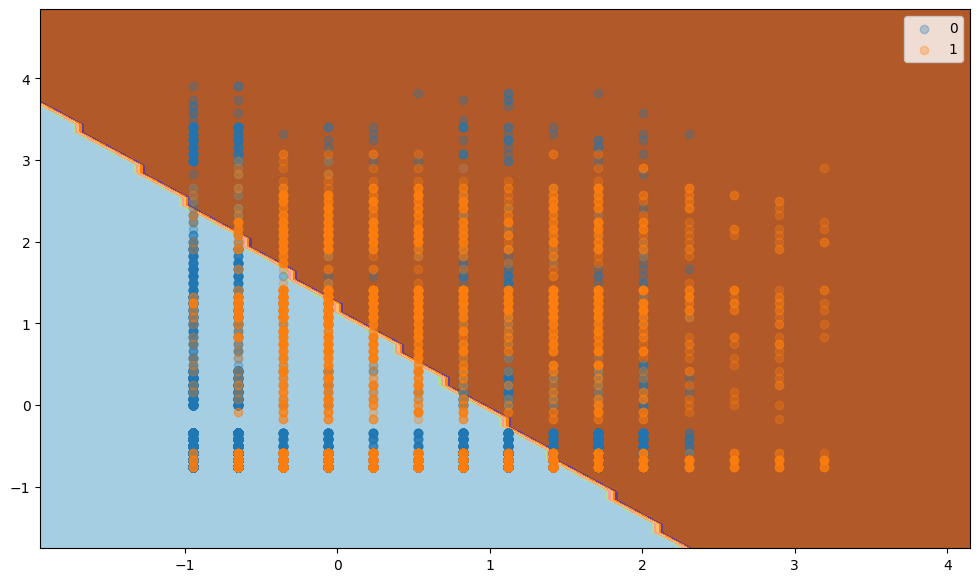

In [21]:
from numpy import where      # funkcja do wyszukiwania elementów spełniających warunek
from numpy import meshgrid   # tworzenie siatki punktów na płaszczyźnie
from numpy import arange     # generowanie zakresu wartości z określonym krokiem
from numpy import hstack     # łączenie tablic poziomo

def plot_classification_surface(X_plot, y_plot, trained_model):

    plt.figure(figsize=(12, 7))  # utworzenie okna wykresu

    # określenie granic zbioru
    min1, max1 = X_plot[:, 0].min()-1, X_plot[:, 0].max()+1  # minimalna i maksymalna wartość pierwszej cechy
    min2, max2 = X_plot[:, 1].min()-1, X_plot[:, 1].max()+1  # minimalna i maksymalna wartość drugiej cechy

    # skalowanie dla obu osi
    x1grid = arange(min1, max1, 0.1)  # punkty na osi X
    x2grid = arange(min2, max2, 0.1)  # punkty na osi Y

    # utworzenie siatki punktów
    xx, yy = meshgrid(x1grid, x2grid)

    # przetworzenie siatki na długie wektory
    r1, r2 = xx.flatten(), yy.flatten()

    # zamiana na kolumny
    r1 = r1.reshape((len(r1), 1))
    r2 = r2.reshape((len(r2), 1))

    # połączenie współrzędnych w zbiór danych
    grid = hstack((r1, r2))

    # predykcja klasy dla każdego punktu siatki
    yhat = trained_model.predict(grid)

    # odtworzenie oryginalnego kształtu siatki
    zz = yhat.reshape(xx.shape)

    # pokolorowanie obszarów zgodnie z przewidywaną klasą
    plt.contourf(xx, yy, zz, cmap='Paired')

    # rysowanie punktów treningowych
    for class_value in range(2):

        # znalezienie indeksów obserwacji należących do danej klasy
        row_ix = where(y_plot == class_value)

        # narysowanie punktów tej klasy
        plt.scatter(
            X_plot[row_ix, 0],
            X_plot[row_ix, 1],
            cmap='Paired',
            alpha=0.3,
            label=class_value
        )

    # dodanie legendy
    plt.legend(loc='upper right')

    # wyświetlenie wykresu
    plt.show()


# wywołanie funkcji dla wytrenowanego modelu
plot_classification_surface(
    X_plot=X_train_standardized,
    y_plot=y_train,
    trained_model=model_lr
)

Ups… Obserwacje nie są liniowo separowane, ale to jest codzienność Data Scientisty – zazwyczaj nie ma prostych problemów do rozwiązania. Niemniej widzimy, gdzie jest więcej obserwacji konkretnej klasy, ponieważ punkty są przezroczyste. Moglibyśmy stworzyć lepszy model, ponieważ jeśli spojrzysz na dokumentację to jednymi z hiperparametramów modelu są rodzaj regularyzacji (l1, l2, elasticnet lub None - żaden) oraz stopień regularyzacji (C). Będzie to zadanie dla Ciebie, ale zanim to nastąpi, sprawdźmy jakie metryki model osiągnął dla zbioru testowego.

# OCENA MODELU

Hm... Jak by tu ocenić model. Na przykład możemy porównać nasze prognozy z wartościami prawdziwym. Zróbmy tak zatem dla 5 pierwszych oraz 5 ostatnich wartości.M

In [22]:
predictions_lr = model_lr.predict(X_test_standardized)  # przewidzenie klas dla danych testowych za pomocą wytrenowanego modelu regresji logistycznej

print('Predicted labels: ', predictions_lr[:5], predictions_lr[-5:])  # wyświetlenie pierwszych 5 i ostatnich 5 przewidzianych etykiet

print('Actual labels:    ', y_test[:5].values, y_test[-5:].values)  # wyświetlenie pierwszych 5 i ostatnich 5 rzeczywistych etykiet ze zbioru testowego

Predicted labels:  [0 0 1 0 0] [1 0 1 0 0]
Actual labels:     [0 1 0 0 0] [1 1 0 0 0]


# tlumaczenie chata

Co robi ten kod?

Po wytrenowaniu modelu:

model_lr.fit(X_train_standardized, y_train)

chcesz sprawdzić, jak model radzi sobie na danych, których wcześniej nie widział.

Do tego służy:

X_test_standardized

czyli zbiór testowy.

Krok 1 — Predykcja
predictions_lr = model_lr.predict(X_test_standardized)

Model dla każdego pacjenta ze zbioru testowego przewiduje:

0 = brak cukrzycy
1 = cukrzyca

Przykładowy wynik:

array([0, 1, 0, 0, 1, 1, 0, ...])

Każdy element odpowiada jednemu pacjentowi.

Krok 2 — Wyświetlenie kilku predykcji
predictions_lr[:5]

oznacza:

pokaż pierwszych 5 przewidywań

Przykład:

array([0, 1, 0, 1, 1])
predictions_lr[-5:]

oznacza:

pokaż ostatnich 5 przewidywań

Przykład:

array([1, 0, 0, 1, 1])
Krok 3 — Wyświetlenie prawdziwych odpowiedzi
y_test[:5].values

Przykład:

array([0, 1, 0, 0, 1])

To rzeczywiste etykiety pacjentów.

Przykładowy wynik
Predicted labels:  [0 1 0 1 1] [1 0 0 1 1]

Actual labels:     [0 1 0 0 1] [1 0 0 1 1]

Porównanie pierwszych obserwacji:

Pacjent	Predykcja	Rzeczywista wartość
1	0	0
2	1	1
3	0	0
4	1	0 ❌
5	1	1

Widzimy, że model pomylił się dla pacjenta nr 4.

Dlaczego pokazujemy tylko 5 pierwszych i 5 ostatnich?

Jeżeli zbiór testowy ma np. 3000 rekordów:

len(y_test)

to wypisanie wszystkiego byłoby nieczytelne.

Dlatego wyświetla się jedynie fragment wyników w celu szybkiej kontroli.

Co można wywnioskować z tego kodu?

Ten fragment pozwala:

sprawdzić, czy model zwraca sensowne wyniki,
porównać kilka przewidywań z rzeczywistymi etykietami,
upewnić się, że predykcja działa poprawnie.

Nie mówi jednak jeszcze, jak dobry jest model. Do tego używa się metryk takich jak:

accuracy_score()
precision_score()
recall_score()
f1_score()
confusion_matrix()

które podsumowują skuteczność modelu na całym zbiorze testowym.

# cd kurs

Taka ocena modelu jest jednak uciążliwa, a czasem niemożliwa jeśli nasz zbiór składa się z wielu obserwacji. Dlatego stosujemy metryki agregujące wyniki naszego modelu. Przykładem może być macierz omyłek, tak – ją już poznaliśmy.

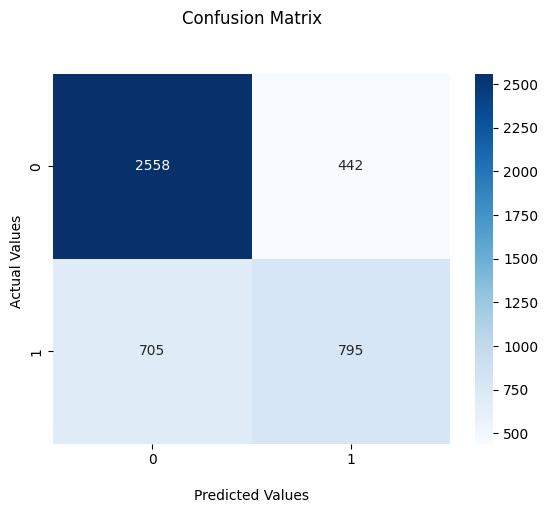

In [23]:
from sklearn.metrics import confusion_matrix  # import funkcji do tworzenia macierzy pomyłek

import seaborn as sns  # import biblioteki seaborn do tworzenia estetycznych wykresów

cm = confusion_matrix(y_test, predictions_lr)  # obliczenie macierzy pomyłek na podstawie wartości rzeczywistych i przewidzianych

ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')  # utworzenie mapy cieplnej przedstawiającej macierz pomyłek

ax.set_title('Confusion Matrix\n\n')  # ustawienie tytułu wykresu

ax.set_xlabel('\nPredicted Values')  # podpis osi X - wartości przewidziane przez model

ax.set_ylabel('Actual Values ')  # podpis osi Y - wartości rzeczywiste

plt.show()  # wyświetlenie wykresu

Co robi ten kod?

Tworzy macierz pomyłek (Confusion Matrix), czyli jedną z najważniejszych metod oceny modelu klasyfikacyjnego.

Dla Twojego problemu:

0 = brak cukrzycy
1 = cukrzyca

macierz może wyglądać tak:

	Pred 0	Pred 1
Actual 0	1200	100
Actual 1	150	550
Jak powstaje macierz?

Funkcja:

confusion_matrix(y_test, predictions_lr)

porównuje:

y_test

czyli prawdziwe etykiety

z

predictions_lr

czyli przewidywaniami modelu.

Interpretacja pól macierzy

Standardowy układ:

	Predicted 0	Predicted 1
Actual 0	TN	FP
Actual 1	FN	TP

gdzie:

TN (True Negative)
Actual = 0
Predicted = 0

Pacjent zdrowy został poprawnie uznany za zdrowego.

FP (False Positive)
Actual = 0
Predicted = 1

Pacjent zdrowy został błędnie uznany za chorego.

FN (False Negative)
Actual = 1
Predicted = 0

Pacjent chory został błędnie uznany za zdrowego.

W medycynie jest to zwykle najgroźniejszy błąd.

TP (True Positive)
Actual = 1
Predicted = 1

Pacjent chory został poprawnie wykryty.

Przykład

Załóżmy wynik:

[[1200  100]
 [ 150  550]]

Oznacza:

Typ	Liczba
TN	1200
FP	100
FN	150
TP	550

Interpretacja:

1200 zdrowych wykryto poprawnie
100 zdrowych uznano za chorych
150 chorych przeoczono
550 chorych wykryto poprawnie
Co robi heatmap?

Ta linia:

sns.heatmap(cm, annot=True, cmap='Blues')

rysuje macierz jako kolorową tabelę.

Parametry:

annot=True

wyświetla liczby wewnątrz komórek.

cmap='Blues'

używa niebieskiej palety kolorów.

Im większa liczba:

ciemniejszy kolor
fmt='.0f'

wyświetla liczby całkowite bez miejsc po przecinku.

Jak ocenić model na podstawie macierzy?

Dobrze, gdy:

TN jest duże,
TP jest duże,
FP jest małe,
FN jest małe.

W problemie wykrywania cukrzycy szczególnie ważne jest:

FN (False Negative)

czyli liczba chorych osób, które model uznał za zdrowe.

Jeżeli FN jest wysokie, model może być niebezpieczny w praktyce, ponieważ przeocza osoby wymagające dalszej diagnostyki.

Dlaczego macierz pomyłek jest ważniejsza od samego Accuracy?

Załóżmy, że:

95% pacjentów jest zdrowych
5% pacjentów jest chorych

Model przewidujący zawsze:

0

osiągnie:

Accuracy = 95%

ale nie wykryje ani jednego chorego pacjenta.

Macierz pomyłek natychmiast pokaże ten problem, ponieważ:

TP = 0
FN = bardzo dużo

Dlatego macierz pomyłek jest podstawowym narzędziem do oceny modeli klasyfikacyjnych, szczególnie w zastosowaniach medycznych takich jak wykrywanie cukrzycy.

# cd KURS

Nasz model nie radzi sobie w pełni z rozdzieleniem obu klas. Gdy model wskazuje na klasę 1, to nie pokrywamy wszystkich obserwacji prawdziwych tej klasy (słaba czułość). Gdy model wskazuje tę klasę, to też 425 się myli (słaba precyzja). Policzmy zatem dokładność, precyzję, czułość oraz F1 score.

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # import metryk oceny modelu klasyfikacyjnego

print('Accuracy: ', accuracy_score(y_test, predictions_lr))  # obliczenie i wyświetlenie dokładności modelu

print("Precision:", precision_score(y_test, predictions_lr))  # obliczenie i wyświetlenie precyzji modelu

print("Recall:", recall_score(y_test, predictions_lr))  # obliczenie i wyświetlenie czułości (Recall)

print("F1_score:", f1_score(y_test, predictions_lr))  # obliczenie i wyświetlenie miary F1

Accuracy:  0.7451111111111111
Precision: 0.6426839126919968
Recall: 0.53
F1_score: 0.5809280233832663


Co robi ten kod?

Po wytrenowaniu modelu i wygenerowaniu predykcji:

predictions_lr = model_lr.predict(X_test_standardized)

chcemy ocenić:

Jak dobrze model przewiduje cukrzycę?

Do tego służą metryki klasyfikacyjne.

1. Accuracy (dokładność)

Obliczana przez:

accuracy_score(y_test, predictions_lr)

Wzór:

Accuracy=
TP+TN+FP+FN
TP+TN
	​


czyli:

Jaki procent wszystkich przewidywań był poprawny?

Przykład:

Rzeczywista	Predykcja
0	0
1	1
0	0
1	0

3 z 4 odpowiedzi są poprawne.

Accuracy = 75%
2. Precision (precyzja)

Wzór:

Precision=
TP+FP
TP
	​


Pokazuje:

Jeśli model powiedział "cukrzyca", jak często miał rację?

Przykład:

Model wskazał 100 osób jako chore.

80 rzeczywiście chorych
20 zdrowych

Wtedy:

Precision=
100
80
	​

=0.8

czyli:

Precision = 80%
3. Recall (czułość)

Wzór:

Recall=
TP+FN
TP
	​


Pokazuje:

Jaki procent wszystkich chorych osób został wykryty?

Przykład:

Mamy 100 chorych pacjentów.

Model wykrył:

90 osób

a przeoczył:

10 osób

Wtedy:

Recall=
100
90
	​

=0.9

czyli:

Recall = 90%
4. F1-score

Wzór:

F1=2⋅
Precision+Recall
Precision⋅Recall
	​


Jest to średnia harmoniczna Precision i Recall.

Pokazuje:

Jak dobrze model równoważy precyzję i czułość.

Przykład:

Precision = 0.80
Recall = 0.90

to:

F1≈0.85
Związek z macierzą pomyłek

Przypomnijmy układ macierzy:

	Pred 0	Pred 1
Actual 0	TN	FP
Actual 1	FN	TP

Na jej podstawie liczone są wszystkie metryki:

Accuracy → wykorzystuje TN, TP, FP, FN
Precision → wykorzystuje TP i FP
Recall → wykorzystuje TP i FN
F1-score → wykorzystuje Precision i Recall
Która metryka jest najważniejsza przy wykrywaniu cukrzycy?

Zwykle bardzo ważny jest Recall.

Dlaczego?

Jeżeli model uzna chorego pacjenta za zdrowego:

Actual = 1
Predicted = 0

powstaje:

False Negative (FN)

czyli przypadek przeoczenia choroby.

W zastosowaniach medycznych często bardziej zależy nam na wysokim Recall niż na maksymalnym Accuracy.

Jak interpretować wyniki?

Przykładowo:

Accuracy:  0.86
Precision: 0.82
Recall:    0.79
F1_score: 0.80

oznacza:

model poprawnie klasyfikuje 86% wszystkich pacjentów,
gdy przewiduje cukrzycę, ma rację w 82% przypadków,
wykrywa 79% wszystkich chorych osób,
ogólna równowaga między Precision i Recall wynosi 80%.
Krótka ściąga
Metryka	Pytanie, na które odpowiada
Accuracy	Jak często model ma rację?
Precision	Jak często przewidziana cukrzyca jest prawdziwa?
Recall	Jaki procent chorych został wykryty?
F1-score	Jak dobrze model równoważy Precision i Recall?

W problemach medycznych (takich jak wykrywanie cukrzycy) zwykle największą uwagę zwraca się na Recall i F1-score, ponieważ samo wysokie Accuracy może ukrywać dużą liczbę niewykrytych przypadków choroby.

# cd kurs

Te same metryki możemy uzyskać, wykorzystując funkcję classification_report z biblioteki sklearn. Wyniki zaokrąglone są do drugiego miejsca po przecinku i jest to jak najbardziej wystarczające.



In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions_lr))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82      3000
           1       0.64      0.53      0.58      1500

    accuracy                           0.75      4500
   macro avg       0.71      0.69      0.70      4500
weighted avg       0.74      0.75      0.74      4500



Wyniki są te same! Kolejna lekcja dla Ciebie – możesz to samo zrobić na kilka różnych sposobów.

Obliczyliśmy metryki, które wprowadziliśmy na początku modułu. Teraz czas na poznanie innej metody oceny klasyfikatorów. Jest to wykresy krzywej ROC (Receiver Operating Characteristic) i pochodnej temu wykresowi metryki AUC (Area Under the Curve). Modele klasyfikacji mogą zwracać prawdopodobieństwo i to wykorzystuje krzywa ROC. Standardowo modele klasyfikacji mają punkt odcięcia na 0.5, tj. jeśli prawdopodobieństwo jest wyższe niż ten punkt odcięcia to klasa jest pozytywna, w przeciwnym razie negatywna. Możemy się zastanowić jak zmienią się wyniki w zależności od punktu odcięcia. Zdarzyć się może, że metryka precyzji jest dla nas niewystarczająca, nie musimy uczyć nowego modelu, aby maksymalizować tą metrykę, wystarczy manipulować punktem odcięcia!

AUC jest to pole znajdujące się pod krzywą ROC, zaś sama krzywa ROC to wykres TPR (True Positives Rate – tzw. czułość) oraz FPR (False Positives Rate – tzw. specyficzność) w zależności od punktu odcięcia. Najlepszym modelem jest ten, który jest najbliżej lewego górnego rogu wykresu, czyli dążymy do TPR równego 1 i FPR równego 0. Krzywa ROC przechodząca przez przekątną jest odzwierciedleniem modelu losowego dla danych zbalansowanych – model wtedy jest tak samo użyteczny co rzut monetą.

Stwórzmy zatem krzywą ROC dla naszego klasyfikatora, którym jest regresja logistyczna oraz wyliczmy metrykę AUC.

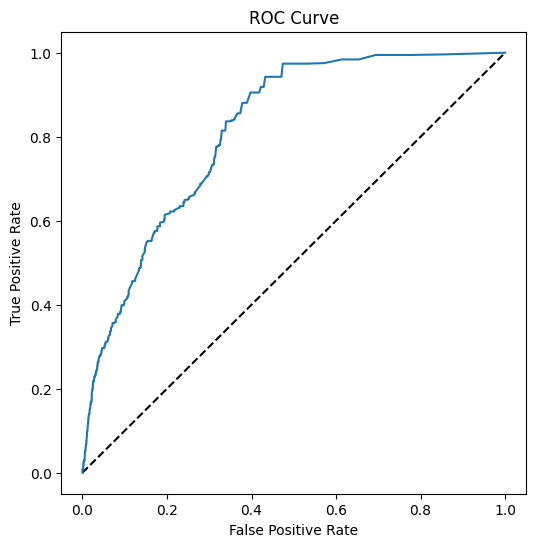

AUC: 0.8164931111111111


In [26]:
from sklearn.metrics import roc_curve  # funkcja do obliczenia punktów krzywej ROC (TPR i FPR)
from sklearn.metrics import roc_auc_score  # funkcja do obliczenia pola pod krzywą ROC (AUC)

# prognoza prawdopodobieństwa
predictions_probability_lr = model_lr.predict_proba(X_test_standardized)  
# zwraca prawdopodobieństwa dla każdej klasy (np. [P(0), P(1)])

# obliczenie FPR oraz TPR w zależności od punktu odcięcia
fpr, tpr, thresholds = roc_curve(y_test, predictions_probability_lr[:,1])  
# ROC liczony dla prawdopodobieństwa klasy 1 (cukrzyca)

# wizualizacja ROC Curve
fig = plt.figure(figsize=(6, 6))  # ustawienie rozmiaru wykresu

# rysowanie prostej dla modelu losowego
plt.plot([0, 1], [0, 1], 'k--')  
# linia odniesienia: model losowy (brak mocy predykcyjnej)

plt.plot(fpr, tpr)  
# właściwa krzywa ROC: zależność TPR od FPR

plt.xlabel('False Positive Rate')  # opis osi X (fałszywie pozytywne)
plt.ylabel('True Positive Rate')  # opis osi Y (prawdziwie pozytywne)
plt.title('ROC Curve')  # tytuł wykresu

plt.show()  # wyświetlenie wykresu

# obliczenie AUC
auc = roc_auc_score(y_test, predictions_probability_lr[:,1])  
# AUC = pole pod krzywą ROC (miara jakości modelu)

print('AUC: ' + str(auc))  # wyświetlenie wyniku AUC


Co robi ten kod?

Ten fragment ocenia model w bardziej „zaawansowany” sposób niż accuracy czy F1-score.

1. Co to jest ROC Curve?

ROC = Receiver Operating Characteristic

Pokazuje zależność:

Oś	Znaczenie
TPR	True Positive Rate (czułość / recall)
FPR	False Positive Rate (fałszywe alarmy)
Jak to działa?

Model nie daje tylko:

0 lub 1

ale daje:

prawdopodobieństwo

np.:

Pacjent	P(cukrzyca)
A	0.10
B	0.80
C	0.55
2. predict_proba
predictions_probability_lr = model_lr.predict_proba(...)

Zwraca:

[ [P(0), P(1)],
  [P(0), P(1)],
  ... ]

np.:

[[0.9, 0.1],
 [0.2, 0.8],
 [0.4, 0.6]]

My bierzemy tylko:

[:,1]

czyli:

prawdopodobieństwo klasy 1 (cukrzyca)

3. ROC curve (fpr, tpr)
fpr, tpr, thresholds = roc_curve(...)

Model testuje wiele progów:

Próg	Co się dzieje
0.2	prawie wszyscy = cukrzyca
0.5	standard
0.8	tylko pewne przypadki

Dla każdego progu liczy:

TPR (Recall) = ile chorych wykryto
FPR = ile zdrowych błędnie uznano za chorych
4. Wykres ROC
plt.plot([0, 1], [0, 1], 'k--')

to linia losowego modelu:

im bardziej blisko tej linii → tym gorzej

Krzywa ROC:

idealny model → lewy górny róg
losowy model → przekątna
5. Co oznacza AUC?
auc = roc_auc_score(...)

AUC = Area Under Curve

czyli:

pole pod krzywą ROC

Interpretacja AUC:
AUC	Znaczenie
1.0	idealny model
0.9–1.0	bardzo dobry
0.8–0.9	dobry
0.7–0.8	średni
0.5	losowy model
6. Dlaczego ROC jest ważne?

Bo:

nie zależy od konkretnego progu (np. 0.5)
pokazuje ogólną jakość modelu
działa dobrze przy niezbalansowanych danych (np. medycyna)
7. Intuicja (najprościej)

ROC mówi:

czy model dobrze oddziela chorych od zdrowych, niezależnie od progu decyzji

8. Co chcesz zobaczyć na dobrym modelu?

✔ krzywa blisko lewego górnego rogu
✔ AUC bliskie 1.0

Podsumowanie

Ten kod:

bierze prawdopodobieństwa predykcji
testuje różne progi klasyfikacji
liczy TPR i FPR
rysuje ROC curve
oblicza AUC jako końcową miarę jakości modelu


# cd kurs

Znamy już metryki, teraz czas aby poznać inne modele. Czy wiesz już, że lenistwo może być pozytywną cechą Data Scientisty? Trochę byśmy dublowali kod za każdym razem wypisując to samo co zrobiliśmy wcześniej, a zmieniając jedynie predykcje w zależności od modelu. Dlatego też stwórzmy funkcję, która oblicza najważniejsze metryki oraz rysuje wykresy. Tę funkcję wykorzystywać będziemy przy ocenie następnych modeli, zatem warto zapisywać najważniejsze metryki (np. f1-score czy AUC) poprzednich modeli, w celu porównawczym.

In [27]:
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])  
# tworzenie pustej tabeli (DataFrame) do zapisywania wyników modeli

metrics_dataframe  # wyświetlenie pustej tabeli

models = []  # lista do przechowywania wytrenowanych modeli
models_names = []  # lista nazw modeli
predictions_proba_list = []  # lista prawdopodobieństw dla klasy 1 (cukrzyca)

def calculate_metrics(model, name, X_checked, y_checked):  # funkcja do oceny modelu

    models.append(model)  # zapisanie modelu do listy
    models_names.append(name)  # zapisanie jego nazwy

    global metrics_dataframe  # użycie globalnej tabeli wyników

    predictions = model.predict(X_checked)  # predykcja klas (0/1)
    predictions_proba = model.predict_proba(X_checked)  # predykcja prawdopodobieństw
    predictions_proba_list.append(predictions_proba[:,1])  # zapis tylko P(klasa=1)

    ############## metryki dla sprawdzanego modelu ################

    print(classification_report(y_checked, predictions))  
    # raport: precision, recall, f1-score, accuracy dla obu klas

    # Confusion matrix
    plt.figure()  # nowy wykres
    cm = confusion_matrix(y_checked, predictions)  # macierz pomyłek
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')  # wizualizacja macierzy
    ax.set_title('Confusion Matrix\n\n')  # tytuł wykresu
    ax.set_xlabel('\nPredicted Values')  # opis osi X
    ax.set_ylabel('Actual Values ')  # opis osi Y
    plt.show()  # pokazanie wykresu

    # plot ROC curve
    fig = plt.figure(figsize=(6, 6))  # ustawienie rozmiaru wykresu
    plt.plot([0, 1], [0, 1], 'k--')  # linia modelu losowego

    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        # przejście przez wszystkie zapisane modele

        fpr, tpr, thresholds = roc_curve(y_checked, pred_proba)  
        # obliczenie ROC dla danego modelu

        plt.plot(fpr, tpr, label=name_selected)  
        # dodanie krzywej ROC do wykresu

    plt.xlabel('False Positive Rate')  # opis osi X
    plt.ylabel('True Positive Rate')  # opis osi Y
    plt.title('ROC Curve')  # tytuł wykresu
    plt.legend(loc='lower right')  # legenda
    plt.show()  # pokazanie wykresu

    f1_metric = f1_score(y_checked, predictions)  
    # obliczenie F1-score

    auc_metric = roc_auc_score(y_checked, predictions_proba[:,1])  
    # obliczenie AUC (pole pod krzywą ROC)

    metrics_dataframe = metrics_dataframe.append(
        {'Model': name, 'F1_score': f1_metric, 'AUC': auc_metric},
        ignore_index=True
    )
    # dodanie wyników modelu do tabeli

    return metrics_dataframe  # zwrócenie tabeli z wynikami

Funkcji podajemy wytrenowany model, jego nazwę (tak będziemy odróżniać modele) oraz X i y ze zbioru testowego.

              precision    recall  f1-score   support

           0       0.78      0.85      0.82      3000
           1       0.64      0.53      0.58      1500

    accuracy                           0.75      4500
   macro avg       0.71      0.69      0.70      4500
weighted avg       0.74      0.75      0.74      4500



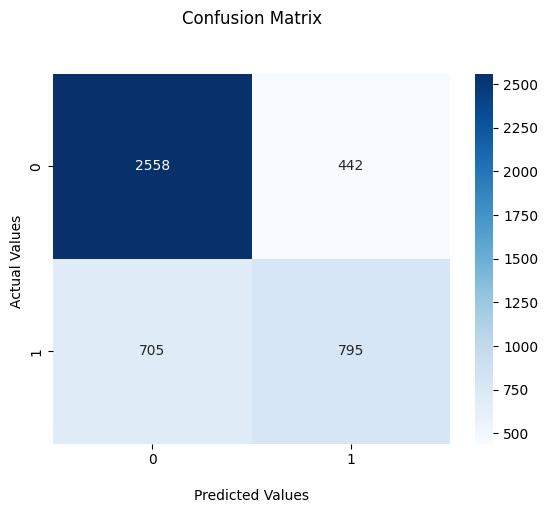

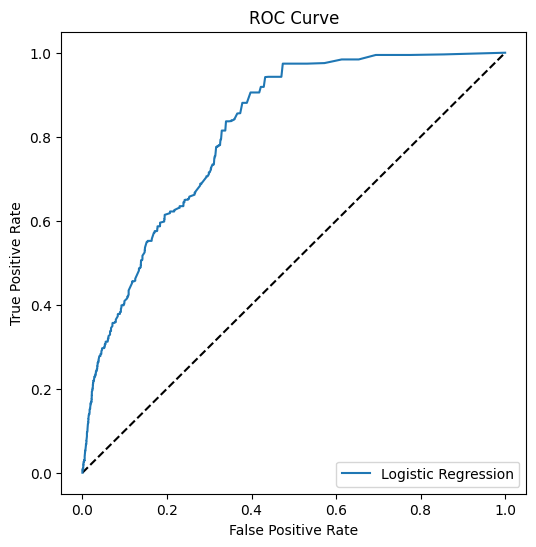

AttributeError: 'DataFrame' object has no attribute 'append'

In [28]:
calculate_metrics(model_lr, 'Logistic Regression', X_test_standardized, y_test)